# Check for the correctness of the REM 

In [72]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.signal import butter, filtfilt, iirnotch

warnings.filterwarnings("ignore", category=RuntimeWarning)

In [73]:
# ---- Paths / IDs ----
# Motion PID can differ from EEG PID (e.g. motion uses Soso, EEG file is EEG_Soso3.csv)
PID_MOTION = "Soso"
PID_EEG = "Soso3"
NIGHT_NUMBER = 1  # 1-based night index from export_data.py
RAW_MOTION_CSV = Path("/Users/solenenoize/Desktop/LuciDreams/plot/data_night/motion_per_second_series.csv")
REM_CSV = Path("/Users/solenenoize/Desktop/LuciDreams/plot/data_night/rem_episodes.csv")
CUE_CSV = Path("/Users/solenenoize/Desktop/LuciDreams/plot/data_night/cue_events.csv")
TRAINS_CSV = Path("/Users/solenenoize/Desktop/LuciDreams/plot/data_night/train_events.csv")
EEG_CSV = Path(f"/Users/solenenoize/Desktop/LuciDreams/plot/EEG/EEG_{PID_EEG}.csv")

# ---- App-like constants ----
REM_GATE_SECONDS = 4 * 60 * 60
REM_EXIT_HOLD_SEC = 10
DISRUPTIVE_PHASE_DURATION_SEC = 120
REFRACTORY_PERIOD_SEC = 300
AROUSAL_CHECK_WINDOW_SEC = 5

# Keep this True to mirror runtime behavior: during disruptive phase we do not exit REM.
APPLY_DISRUPTIVE_EXIT_SUPPRESSION = True
# Also mirror runtime re-entry block after a train ends.
APPLY_REFRACTORY_ENTRY_BLOCK = True

# Default run config (you can override per experiment cell)
SMOOTH_WINDOW_SEC = 120
REM_STILLNESS_PERCENT = 0.80
PER_REM_PRE_SEC = 60
PER_REM_POST_SEC = 60

# Real smoothed CSV is indexed from first valid smoothed sample (starts at 0),
# while REM epochs are absolute night seconds.
# For app REM smoothing window=180s, absolute second = csv_second_index + 179.
REAL_SMOOTH_INDEX_OFFSET_SEC = 179

# EEG plotting config (inline only; no file saving)
EEG_BIN_SEC = 0.5
BANDPASS_LOW_HZ = 0.5
BANDPASS_HIGH_HZ = 40.0
NOTCH_HZ = 60.0
NOTCH_Q = 30.0
PER_REM_LOWPASS_HZ = 40.0

In [74]:
def choose_session(df_motion: pd.DataFrame, pid: str, night_number: int | None = None) -> pd.DataFrame:
    d = df_motion.copy()
    d["pid"] = d["pid"].astype(str)
    out = d[d["pid"] == str(pid)].copy()
    if out.empty:
        available = sorted(d["pid"].dropna().astype(str).unique().tolist())
        raise ValueError(f"No rows for pid {pid}. Available pids: {available[:15]}")

    if night_number is not None and "night_number" in out.columns:
        out["night_number"] = pd.to_numeric(out["night_number"], errors="coerce")
        out = out[out["night_number"] == int(night_number)].copy()
        if out.empty:
            raise ValueError(f"No rows for pid {pid} and night_number {night_number}")

    out["second_index"] = pd.to_numeric(out["second_index"], errors="coerce")
    out["motion_per_second"] = pd.to_numeric(out["motion_per_second"], errors="coerce")
    out = out.dropna(subset=["second_index", "motion_per_second"]).copy()
    out["second_index"] = out["second_index"].astype(int)
    out = out.sort_values("second_index").reset_index(drop=True)

    sess_col = "session_start_boston" if "session_start_boston" in out.columns else "session_start"
    if sess_col not in out.columns:
        raise ValueError("Missing session start column in motion CSV")

    # Keep one night: choose the session with most rows for this pid.
    out["_sess"] = out[sess_col].astype(str)
    best_session = out.groupby("_sess").size().sort_values(ascending=False).index[0]
    out = out[out["_sess"] == best_session].copy()
    out["session_start_boston"] = pd.to_datetime(out[sess_col], errors="coerce")
    out = out.dropna(subset=["session_start_boston"]).reset_index(drop=True)
    out["event_time_boston"] = out["session_start_boston"] + pd.to_timedelta(out["second_index"], unit="s")
    return out


def build_disruptive_suppression_mask(
    cue_df: pd.DataFrame,
    pid: str,
    night_number: int | None,
    session_start_hms: str,
    disruptive_duration_sec: int,
) -> set[int]:
    if cue_df is None or cue_df.empty:
        return set()

    d = cue_df.copy()
    d = d[d["pid"].astype(str) == str(pid)].copy()

    if night_number is not None and "night_number" in d.columns:
        d["night_number"] = pd.to_numeric(d["night_number"], errors="coerce")
        d = d[d["night_number"] == int(night_number)].copy()

    if "session_start_boston" in d.columns and session_start_hms:
        d = d[d["session_start_boston"].astype(str) == str(session_start_hms)].copy()

    if "cue_type" in d.columns:
        d = d[d["cue_type"].astype(str).str.lower() == "disruptive"].copy()
    if "took_place" in d.columns:
        d = d[d["took_place"].astype(str).str.lower() == "true"].copy()

    d["epoch_sec"] = pd.to_numeric(d.get("epoch_sec"), errors="coerce")
    d = d.dropna(subset=["epoch_sec"]).copy()

    mask = set()
    dur = max(1, int(disruptive_duration_sec))
    for s in d["epoch_sec"].astype(int).tolist():
        for sec in range(s, s + dur):
            mask.add(int(sec))
    return mask


def build_refractory_entry_block_mask_from_cues(
    cue_df: pd.DataFrame,
    pid: str,
    night_number: int | None,
    session_start_hms: str,
    refractory_period_sec: int,
    arousal_check_window_sec: int,
) -> set[int]:
    """
    Approximate app's lastCueEpoch-based entry block from exported cue rows.
    We estimate train end ~= max cue epoch in train + arousal_check_window_sec,
    then block REM episode entry for the following refractory period.
    """
    if cue_df is None or cue_df.empty:
        return set()

    d = cue_df.copy()
    d = d[d["pid"].astype(str) == str(pid)].copy()

    if night_number is not None and "night_number" in d.columns:
        d["night_number"] = pd.to_numeric(d["night_number"], errors="coerce")
        d = d[d["night_number"] == int(night_number)].copy()

    if "session_start_boston" in d.columns and session_start_hms:
        d = d[d["session_start_boston"].astype(str) == str(session_start_hms)].copy()

    if "took_place" in d.columns:
        d = d[d["took_place"].astype(str).str.lower() == "true"].copy()

    if "episode_index" not in d.columns or "train_index" not in d.columns:
        return set()

    d["episode_index"] = pd.to_numeric(d["episode_index"], errors="coerce")
    d["train_index"] = pd.to_numeric(d["train_index"], errors="coerce")
    d["epoch_sec"] = pd.to_numeric(d.get("epoch_sec"), errors="coerce")
    d = d.dropna(subset=["episode_index", "train_index", "epoch_sec"]).copy()
    if d.empty:
        return set()

    refr = max(1, int(refractory_period_sec))
    lag = max(0, int(arousal_check_window_sec))

    mask = set()
    grouped = d.groupby(["episode_index", "train_index"], as_index=False)["epoch_sec"].max()
    for _, row in grouped.iterrows():
        train_end_est = int(row["epoch_sec"]) + lag
        # In app: refractoryOk when (secondsRecorded - lastCueEpoch) >= REFRACTORY_PERIOD_SEC.
        # So block entry for [lastCueEpoch+1, lastCueEpoch+REFRACTORY-1].
        start_block = train_end_est + 1
        end_block = train_end_est + refr - 1
        for sec in range(start_block, end_block + 1):
            mask.add(int(sec))
    return mask


def build_runtime_masks_from_train_events(
    train_df: pd.DataFrame,
    rem_df: pd.DataFrame,
    pid: str,
    night_number: int | None,
) -> tuple[set[int], set[int]]:
    """
    Build runtime masks from exported train timeline:
    - disruptive mask: disruptive_start_epoch_sec .. first_induction_epoch_sec (inclusive)
    - refractory entry block (lastCueEpoch-like): only for trains that ended before episode end
      (heuristic for true endTrain() rather than finalizeCurrentRemEpisode).
    """
    if train_df is None or train_df.empty:
        return set(), set()

    d = train_df.copy()
    d = d[d["pid"].astype(str) == str(pid)].copy()

    if night_number is not None and "night_number" in d.columns:
        d["night_number"] = pd.to_numeric(d["night_number"], errors="coerce")
        d = d[d["night_number"] == int(night_number)].copy()

    if d.empty:
        return set(), set()

    # Episode-end map from rem rows (episode_index -> episode_end_sec)
    rem_ep_end = {}
    if rem_df is not None and not rem_df.empty:
        rr = rem_df.copy()
        rr = rr[rr["pid"].astype(str) == str(pid)].copy()
        if night_number is not None and "night_number" in rr.columns:
            rr["night_number"] = pd.to_numeric(rr["night_number"], errors="coerce")
            rr = rr[rr["night_number"] == int(night_number)].copy()
        rr["episode_index"] = pd.to_numeric(rr.get("episode_index"), errors="coerce")
        rr["episode_start_epoch_sec"] = pd.to_numeric(rr.get("episode_start_epoch_sec"), errors="coerce")
        rr["episode_duration_sec"] = pd.to_numeric(rr.get("episode_duration_sec"), errors="coerce")
        rr = rr.dropna(subset=["episode_index", "episode_start_epoch_sec", "episode_duration_sec"]).copy()
        for _, r in rr.iterrows():
            rem_ep_end[int(r["episode_index"])] = int(r["episode_start_epoch_sec"] + r["episode_duration_sec"])

    for c in ["episode_index", "disruptive_start_epoch_sec", "first_induction_epoch_sec", "train_end_epoch_sec", "disruptive_took_place"]:
        if c in d.columns:
            d[c] = pd.to_numeric(d[c], errors="coerce") if c != "disruptive_took_place" else d[c]

    disruptive_mask = set()
    refractory_mask = set()

    for _, row in d.iterrows():
        took = str(row.get("disruptive_took_place", "")).lower() == "true"
        ep_idx = row.get("episode_index")
        ds = row.get("disruptive_start_epoch_sec")
        fi = row.get("first_induction_epoch_sec")
        te = row.get("train_end_epoch_sec")

        # Exact disruptive phase window when we have both boundaries.
        if took and pd.notna(ds):
            ds_i = int(ds)
            if pd.notna(fi):
                fi_i = int(fi)
                # Include the first induction second to match runtime ordering edge.
                for sec in range(ds_i, max(ds_i, fi_i) + 1):
                    disruptive_mask.add(int(sec))
            else:
                # Fallback if no induction boundary in export.
                for sec in range(ds_i, ds_i + max(1, int(DISRUPTIVE_PHASE_DURATION_SEC))):
                    disruptive_mask.add(int(sec))

        # Refractory block only when train ended before episode end (endTrain-like).
        if pd.notna(te):
            te_i = int(te)
            ep_end = None
            if pd.notna(ep_idx):
                ep_end = rem_ep_end.get(int(ep_idx))
            if ep_end is not None and te_i >= ep_end:
                # Likely finalized by REM exit; app does not update lastCueEpoch there.
                continue
            for sec in range(te_i + 1, te_i + max(1, int(REFRACTORY_PERIOD_SEC))):
                refractory_mask.add(int(sec))

    return disruptive_mask, refractory_mask


def compute_smoothed_like_app(raw_series: pd.Series, window_sec: int) -> pd.Series:
    """
    Exact app-like smoothing:
    - Append each raw value into a rolling buffer
    - Keep only last `window_sec` values
    - Emit NaN until buffer is full
    - Then emit rolling mean
    """
    vals = pd.to_numeric(raw_series, errors="coerce").astype(float).tolist()
    out = []
    buf = []
    rolling_sum = 0.0

    for v in vals:
        if not np.isfinite(v):
            out.append(np.nan)
            continue
        buf.append(v)
        rolling_sum += v
        if len(buf) > window_sec:
            rolling_sum -= buf.pop(0)

        if len(buf) >= window_sec:
            out.append(rolling_sum / len(buf))
        else:
            out.append(np.nan)

    return pd.Series(out, index=raw_series.index, dtype=float)


def is_still_smoothed(smoothed_history, current_smoothed, pct=0.8):
    values = [v for v in smoothed_history if np.isfinite(v)]
    if len(values) == 0 or not np.isfinite(current_smoothed):
        return False
    below_count = sum(1 for v in values if float(current_smoothed) < float(v))
    return (below_count / len(values)) >= float(pct)


def simulate_rem_episodes_exact_app(
    df: pd.DataFrame,
    stillness_pct: float,
    rem_gate_seconds: int,
    rem_exit_hold_sec: int,
    disruptive_suppress_mask: set[int] | None = None,
    refractory_entry_block_mask: set[int] | None = None,
) -> pd.DataFrame:
    """
    Mirrors app REM state-machine, including runtime behavior where REM exit is blocked
    during disruptive phase windows.
    - secondsRecorded = second_index + 1 (1-based)
    - smoothed history grows whenever current smoothed exists
    - afterGate required before REM logic runs
    - immediate entry when stillness is true
    - exit after `rem_exit_hold_sec` consecutive non-still seconds
    - duration_sec = end_sec - start_sec
    """
    in_rem = False
    consecutive_non_still = 0
    rem_start_sec = None
    episodes = []
    smoothed_history = []

    for _, row in df.iterrows():
        sec_idx = int(row["second_index"])
        sec_rec = sec_idx + 1
        sm_val = row["motion_smoothed_current_exp"] if "motion_smoothed_current_exp" in row else row["motion_smoothed_exp"]
        sm = float(sm_val) if np.isfinite(sm_val) else np.nan

        if np.isfinite(sm):
            smoothed_history.append(sm)

        after_gate = (sec_rec > rem_gate_seconds) and (len(smoothed_history) > 0) and np.isfinite(sm)
        if not after_gate:
            in_rem = False
            consecutive_non_still = 0
            rem_start_sec = None
            continue

        still = is_still_smoothed(smoothed_history, sm, stillness_pct)

        if not in_rem:
            if still:
                if refractory_entry_block_mask and sec_rec in refractory_entry_block_mask:
                    # App refractory gate: cannot start a new REM episode too soon after last cue/train.
                    continue
                rem_start_sec = sec_rec
                in_rem = True
                consecutive_non_still = 0
        else:
            if still:
                consecutive_non_still = 0
            else:
                # App runtime behavior: while disruptive phase is active, do not exit REM.
                # IMPORTANT: cue epoch_sec is app 1-based secondsRecorded, so compare with sec_rec.
                if disruptive_suppress_mask and sec_rec in disruptive_suppress_mask:
                    consecutive_non_still = 0
                else:
                    consecutive_non_still += 1
                    if consecutive_non_still >= rem_exit_hold_sec:
                        end_sec = sec_rec
                        episodes.append({
                            "episode_index": len(episodes),
                            "start_sec": int(rem_start_sec),
                            "end_sec": int(end_sec),
                            "duration_sec": int(end_sec - rem_start_sec),
                        })
                        in_rem = False
                        consecutive_non_still = 0
                        rem_start_sec = None

    if in_rem and rem_start_sec is not None:
        end_sec = int(df["second_index"].max()) + 1
        episodes.append({
            "episode_index": len(episodes),
            "start_sec": int(rem_start_sec),
            "end_sec": int(end_sec),
            "duration_sec": int(end_sec - rem_start_sec),
        })

    rem_df = pd.DataFrame(episodes)
    if rem_df.empty:
        return rem_df

    start0 = pd.to_datetime(df["session_start_boston"].iloc[0])
    rem_df["session_start_boston"] = start0
    rem_df["episode_start_boston"] = start0 + pd.to_timedelta(rem_df["start_sec"], unit="s")
    rem_df["episode_end_boston"] = start0 + pd.to_timedelta(rem_df["end_sec"], unit="s")
    return rem_df


In [75]:
def robust_zscore(series: pd.Series) -> pd.Series:
    x = pd.to_numeric(series, errors="coerce").astype(float)
    med = np.nanmedian(x)
    mad = np.nanmedian(np.abs(x - med))
    if not np.isfinite(mad) or mad < 1e-12:
        std = np.nanstd(x)
        if not np.isfinite(std) or std < 1e-12:
            return x * 0.0
        return (x - med) / std
    return 0.6745 * (x - med) / mad


def estimate_sampling_hz(ts: pd.Series) -> float:
    t = pd.to_datetime(ts, errors="coerce").dropna().sort_values()
    if len(t) < 3:
        return np.nan
    dt = t.diff().dropna().dt.total_seconds().values
    dt = dt[np.isfinite(dt) & (dt > 0)]
    if len(dt) == 0:
        return np.nan
    return 1.0 / np.median(dt)


def bandpass_notch_filter(x: np.ndarray, fs: float, low_hz: float, high_hz: float, notch_hz: float, notch_q: float) -> np.ndarray:
    y = np.asarray(x, dtype=float)
    if not np.isfinite(fs) or fs <= 0:
        return y
    nyq = 0.5 * fs

    if 0 < low_hz < high_hz < nyq:
        b, a = butter(4, [low_hz / nyq, high_hz / nyq], btype="band")
        y = filtfilt(b, a, y)

    if 0 < notch_hz < nyq:
        b, a = iirnotch(notch_hz / nyq, notch_q)
        y = filtfilt(b, a, y)

    return y


def lowpass_filter(x: np.ndarray, fs: float, cutoff_hz: float) -> np.ndarray:
    y = np.asarray(x, dtype=float)
    if not np.isfinite(fs) or fs <= 0:
        return y
    nyq = 0.5 * fs
    if not (0 < cutoff_hz < nyq):
        return y
    b, a = butter(4, cutoff_hz / nyq, btype="low")
    return filtfilt(b, a, y)


def load_and_prepare_eeg(eeg_csv: Path) -> pd.DataFrame:
    if not eeg_csv.exists():
        raise FileNotFoundError(f"EEG file not found: {eeg_csv}")

    eeg = pd.read_csv(eeg_csv)

    # Support both Muse timestamp variants seen in exports.
    ts_col = None
    if "Timestamp" in eeg.columns:
        ts_col = "Timestamp"
    elif "TimeStamp" in eeg.columns:
        ts_col = "TimeStamp"

    required_signal = {"RAW_AF7", "RAW_AF8"}
    missing_signal = [c for c in required_signal if c not in eeg.columns]
    if ts_col is None:
        raise ValueError("Missing EEG timestamp column: expected 'Timestamp' or 'TimeStamp'")
    if missing_signal:
        raise ValueError(f"Missing EEG columns: {missing_signal}")

    eeg = eeg.copy()
    eeg["timestamp_boston"] = pd.to_datetime(eeg[ts_col], errors="coerce")
    eeg["RAW_AF7"] = pd.to_numeric(eeg["RAW_AF7"], errors="coerce")
    eeg["RAW_AF8"] = pd.to_numeric(eeg["RAW_AF8"], errors="coerce")
    eeg = eeg.dropna(subset=["timestamp_boston", "RAW_AF7", "RAW_AF8"]).sort_values("timestamp_boston").reset_index(drop=True)

    fs = estimate_sampling_hz(eeg["timestamp_boston"])
    if np.isfinite(fs) and fs > 1:
        eeg["RAW_AF7"] = bandpass_notch_filter(eeg["RAW_AF7"].values, fs, BANDPASS_LOW_HZ, BANDPASS_HIGH_HZ, NOTCH_HZ, NOTCH_Q)
        eeg["RAW_AF8"] = bandpass_notch_filter(eeg["RAW_AF8"].values, fs, BANDPASS_LOW_HZ, BANDPASS_HIGH_HZ, NOTCH_HZ, NOTCH_Q)

    eeg["af7_z"] = robust_zscore(eeg["RAW_AF7"])
    eeg["af8_z"] = robust_zscore(eeg["RAW_AF8"])

    # Aggregate to fixed bins for readability.
    t0 = eeg["timestamp_boston"].iloc[0]
    sec = (eeg["timestamp_boston"] - t0).dt.total_seconds()
    bin_idx = np.floor(sec / EEG_BIN_SEC).astype(int)
    eeg["_bin"] = bin_idx

    agg = eeg.groupby("_bin", as_index=False).agg(
        timestamp_boston=("timestamp_boston", "min"),
        af7_z=("af7_z", "mean"),
        af8_z=("af8_z", "mean"),
    )

    fs_agg = 1.0 / EEG_BIN_SEC
    agg["af7_z"] = lowpass_filter(agg["af7_z"].values, fs_agg, PER_REM_LOWPASS_HZ)
    agg["af8_z"] = lowpass_filter(agg["af8_z"].values, fs_agg, PER_REM_LOWPASS_HZ)
    return agg


In [76]:
def _build_motion_sec_maps(df: pd.DataFrame, sec_offset: int = 0):
    """Build sec->(value,time) maps exactly like plot_motion_rem.py style."""
    from datetime import datetime

    def parse_hms_local(v: str):
        try:
            return datetime.strptime(str(v), "%H:%M:%S")
        except Exception:
            return None

    sec_to_val = {}
    sec_to_time = {}
    d = df.copy()
    d["second_index"] = pd.to_numeric(d.get("second_index"), errors="coerce")

    if "motion_smoothed_exp" in d.columns:
        d["_motion_val"] = pd.to_numeric(d.get("motion_smoothed_exp"), errors="coerce")
    else:
        d["_motion_val"] = pd.to_numeric(d.get("motion_smoothed"), errors="coerce")

    d = d.dropna(subset=["second_index"]).copy()
    d["second_index"] = d["second_index"].astype(int)

    if "time_boston" in d.columns:
        d["_plot_time"] = d["time_boston"].apply(parse_hms_local)
    else:
        # Fallback to event_time_boston clock if needed.
        d["_plot_time"] = pd.to_datetime(d.get("event_time_boston"), errors="coerce")

    for _, row in d.iterrows():
        sec = int(row["second_index"]) + int(sec_offset)
        val = row.get("_motion_val")
        t = row.get("_plot_time")
        if pd.isna(val) or pd.isna(t):
            continue
        sec_to_val[sec] = float(val)
        sec_to_time[sec] = t

    return sec_to_val, sec_to_time


def plot_motion_per_rem(rem_df: pd.DataFrame, sec_to_val: dict, sec_to_time: dict, title_prefix: str, pre_sec: int = 60, post_sec: int = 60):
    """Plot motion panels using the exact per-second windowing style of plot_motion_rem.py."""
    if rem_df.empty:
        print("No REM episodes with current settings")
        return

    rr = rem_df.copy()
    rr["episode_index"] = pd.to_numeric(rr.get("episode_index"), errors="coerce")
    if "dur_sec" not in rr.columns:
        rr["dur_sec"] = pd.to_numeric(rr.get("duration_sec"), errors="coerce")
    rr["start_sec"] = pd.to_numeric(rr.get("start_sec"), errors="coerce")
    rr = rr.dropna(subset=["episode_index", "start_sec", "dur_sec"]).copy()
    rr["episode_index"] = rr["episode_index"].astype(int)
    rr["start_sec"] = rr["start_sec"].astype(int)
    rr["dur_sec"] = rr["dur_sec"].astype(int)
    rr = rr.sort_values("episode_index")

    for _, ep in rr.iterrows():
        eidx = int(ep["episode_index"])
        start_sec = int(ep["start_sec"])
        end_sec = int(ep["start_sec"] + ep["dur_sec"])
        win_start_sec = max(0, start_sec - max(0, int(pre_sec)))
        win_end_sec = end_sec + max(0, int(post_sec))

        xs, ys = [], []
        for sec in range(win_start_sec, win_end_sec + 1):
            if sec not in sec_to_val or sec not in sec_to_time:
                continue
            xs.append(sec_to_time[sec])
            ys.append(round(sec_to_val[sec], 3))

        if not xs:
            continue

        fig, ax = plt.subplots(figsize=(12, 4))
        ax.plot(xs, ys, color="tab:blue", linewidth=1.2, marker="o", markersize=2, label="motion smoothed")

        rem_start_t = sec_to_time.get(start_sec)
        rem_end_t = sec_to_time.get(end_sec)
        if rem_start_t is not None and rem_end_t is not None:
            ax.axvspan(rem_start_t, rem_end_t, alpha=0.12, color="tab:orange", label="REM window")
        if rem_start_t is not None:
            ax.axvline(rem_start_t, color="yellow", linestyle="--", linewidth=1.0, alpha=0.95, label="REM start")
        if rem_end_t is not None:
            ax.axvline(rem_end_t, color="black", linestyle="--", linewidth=1.0, alpha=0.95, label="REM end")

        ax.set_title(f"{title_prefix} | REM {eidx}")
        ax.set_xlabel("Time (Boston)")
        ax.set_ylabel("motion_smoothed")
        ax.grid(True, alpha=0.25)
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M:%S"))
        ax.tick_params(axis="x", labelrotation=30, labelsize=8)
        ax.legend(loc="upper right", fontsize=8)
        plt.show()


def plot_eeg_per_rem(eeg_df: pd.DataFrame, rem_df: pd.DataFrame, title_prefix: str, pre_sec: int = 60, post_sec: int = 60):
    if rem_df.empty:
        print("No simulated REM episodes with current settings")
        return

    for _, ep in rem_df.iterrows():
        eidx = int(ep["episode_index"])
        rem_start = pd.to_datetime(ep["episode_start_boston"])
        rem_end = pd.to_datetime(ep["episode_end_boston"])
        t0 = rem_start - pd.to_timedelta(pre_sec, unit="s")
        t1 = rem_end + pd.to_timedelta(post_sec, unit="s")

        d = eeg_df[(eeg_df["timestamp_boston"] >= t0) & (eeg_df["timestamp_boston"] <= t1)].copy()
        if d.empty:
            continue

        rel_sec = (d["timestamp_boston"] - rem_start).dt.total_seconds()

        fig, ax = plt.subplots(figsize=(12, 4))
        ax.plot(rel_sec, d["af7_z"], lw=1.0, color="tab:purple", label="AF7 (z)")
        ax.plot(rel_sec, d["af8_z"], lw=1.0, color="tab:orange", label="AF8 (z)")
        ax.axvline(0, color="yellow", lw=2, label="REM start")
        ax.axvline((rem_end - rem_start).total_seconds(), color="black", lw=2, label="REM end")

        ax.set_title(f"{title_prefix} | EEG around REM {eidx}")
        ax.set_xlabel("Relative time from REM start (s)")
        ax.set_ylabel("Filtered normalized EEG")
        ax.grid(alpha=0.2)
        ax.legend(loc="upper right")
        plt.show()


In [77]:
# Load motion and prepare current night
motion_all = pd.read_csv(RAW_MOTION_CSV)
motion_df = choose_session(motion_all, PID_MOTION, night_number=NIGHT_NUMBER)
session_start_hms = motion_df["session_start_boston"].iloc[0].strftime("%H:%M:%S")
print(
    f"Motion PID={PID_MOTION} | night={NIGHT_NUMBER} | rows={len(motion_df)} | session_start={motion_df['session_start_boston'].iloc[0]}"
)

# Build runtime masks from real train timeline when available, else fallback to cue approximation.
if TRAINS_CSV.exists():
    train_df = pd.read_csv(TRAINS_CSV)
    rem_real_df = pd.read_csv(REM_CSV) if REM_CSV.exists() else pd.DataFrame()
    disruptive_suppress_mask, refractory_entry_block_mask = build_runtime_masks_from_train_events(
        train_df=train_df,
        rem_df=rem_real_df,
        pid=PID_MOTION,
        night_number=NIGHT_NUMBER,
    )
    print("Runtime masks source: train_events.csv (+ rem_episodes.csv)")
else:
    cue_df = pd.read_csv(CUE_CSV)
    disruptive_suppress_mask = build_disruptive_suppression_mask(
        cue_df=cue_df,
        pid=PID_MOTION,
        night_number=NIGHT_NUMBER,
        session_start_hms=session_start_hms,
        disruptive_duration_sec=DISRUPTIVE_PHASE_DURATION_SEC,
    )
    refractory_entry_block_mask = build_refractory_entry_block_mask_from_cues(
        cue_df=cue_df,
        pid=PID_MOTION,
        night_number=NIGHT_NUMBER,
        session_start_hms=session_start_hms,
        refractory_period_sec=REFRACTORY_PERIOD_SEC,
        arousal_check_window_sec=AROUSAL_CHECK_WINDOW_SEC,
    )
    print("Runtime masks source: cue_events.csv fallback")

print(f"Disruptive suppression seconds loaded: {len(disruptive_suppress_mask)}")
print(f"Refractory entry-block seconds loaded: {len(refractory_entry_block_mask)}")

# Load EEG once
eeg_df = load_and_prepare_eeg(EEG_CSV)
print(f"EEG PID={PID_EEG} | file={EEG_CSV.name} | rows after preprocessing={len(eeg_df)}")


Motion PID=Soso | night=1 | rows=32855 | session_start=2026-04-07 23:56:38
Runtime masks source: train_events.csv (+ rem_episodes.csv)
Disruptive suppression seconds loaded: 590
Refractory entry-block seconds loaded: 598


/var/folders/jh/7bzv7c2d0b1f41k5dzy9gxw80000gn/T/ipykernel_14993/3703759433.py:56: DtypeWarning: Columns (39) have mixed types. Specify dtype option on import or set low_memory=False.
  eeg = pd.read_csv(eeg_csv)


EEG PID=Soso3 | file=EEG_Soso3.csv | rows after preprocessing=68046


In [78]:
def run_experiment(window_sec: int, stillness_pct: float, label: str):
    d = motion_df.copy()

    # Current smoothed value per second (NaN before window is full) for REM state-machine.
    d["motion_smoothed_current_exp"] = compute_smoothed_like_app(d["motion_per_second"], window_sec)

    suppress_mask = disruptive_suppress_mask if APPLY_DISRUPTIVE_EXIT_SUPPRESSION else set()
    entry_block_mask = refractory_entry_block_mask if APPLY_REFRACTORY_ENTRY_BLOCK else set()
    rem_df = simulate_rem_episodes_exact_app(
        d,
        stillness_pct=stillness_pct,
        rem_gate_seconds=REM_GATE_SECONDS,
        rem_exit_hold_sec=REM_EXIT_HOLD_SEC,
        disruptive_suppress_mask=suppress_mask,
        refractory_entry_block_mask=entry_block_mask,
    )

    # App-like persisted smoothed series: no NaN prefill rows.
    d_plot = d[d["motion_smoothed_current_exp"].notna()].copy()
    # Match app/export compaction precision for smoothed series.
    d_plot["motion_smoothed_exp"] = d_plot["motion_smoothed_current_exp"].round(3)

    print(
        f"\n[{label}] window={window_sec}s | stillness={stillness_pct:.2f} | "
        f"suppression={'on' if APPLY_DISRUPTIVE_EXIT_SUPPRESSION else 'off'} | "
        f"refractory={'on' if APPLY_REFRACTORY_ENTRY_BLOCK else 'off'} | episodes={len(rem_df)} | "
        f"smoothed_points={len(d_plot)}"
    )
    if not rem_df.empty:
        display(rem_df[["episode_index", "start_sec", "end_sec", "duration_sec", "episode_start_boston", "episode_end_boston"]])

    sec_to_val, sec_to_time = _build_motion_sec_maps(d_plot, sec_offset=0)

    rem_plot = rem_df.copy()
    rem_plot["dur_sec"] = pd.to_numeric(rem_plot.get("duration_sec"), errors="coerce")

    plot_motion_per_rem(rem_plot, sec_to_val, sec_to_time, title_prefix=label, pre_sec=PER_REM_PRE_SEC, post_sec=PER_REM_POST_SEC)
    plot_eeg_per_rem(eeg_df, rem_df, title_prefix=label, pre_sec=PER_REM_PRE_SEC, post_sec=PER_REM_POST_SEC)
    return d_plot, rem_df



in / 80%] window=180s | stillness=0.80 | suppression=on | refractory=on | episodes=8 | smoothed_points=32676


,episode_index,start_sec,end_sec,duration_sec,episode_start_boston,episode_end_boston
0,0,16540,16836,296,2026-04-08 04:32:18,2026-04-08 04:37:14
1,1,19516,20385,869,2026-04-08 05:21:54,2026-04-08 05:36:23
2,2,20558,20642,84,2026-04-08 05:39:16,2026-04-08 05:40:40
3,3,20815,21062,247,2026-04-08 05:43:33,2026-04-08 05:47:40
4,4,23708,23750,42,2026-04-08 06:31:46,2026-04-08 06:32:28
5,5,24426,24454,28,2026-04-08 06:43:44,2026-04-08 06:44:12
6,6,25453,25700,247,2026-04-08 07:00:51,2026-04-08 07:04:58
7,7,25721,25780,59,2026-04-08 07:05:19,2026-04-08 07:06:18


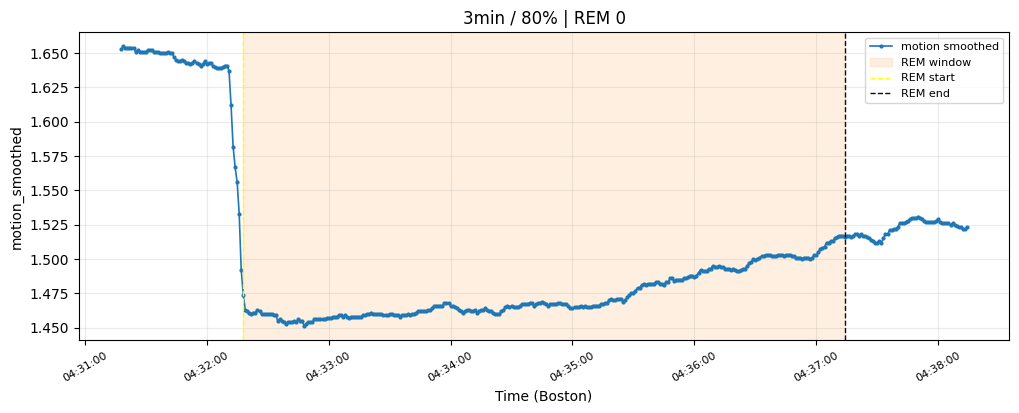

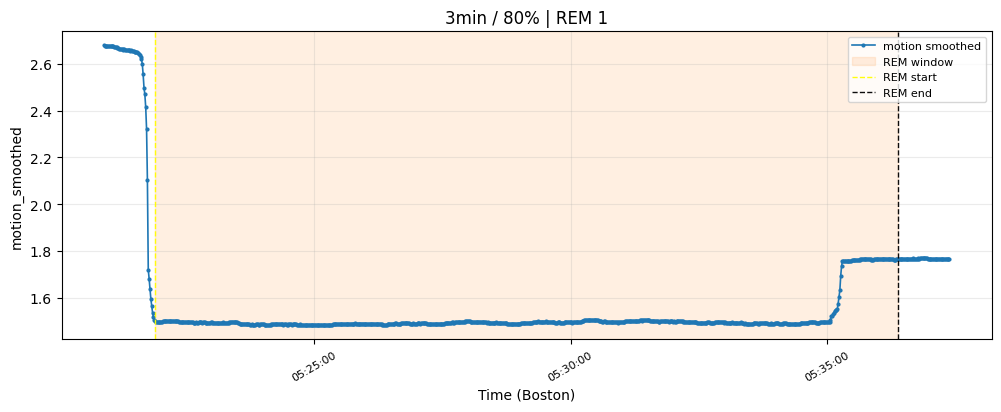

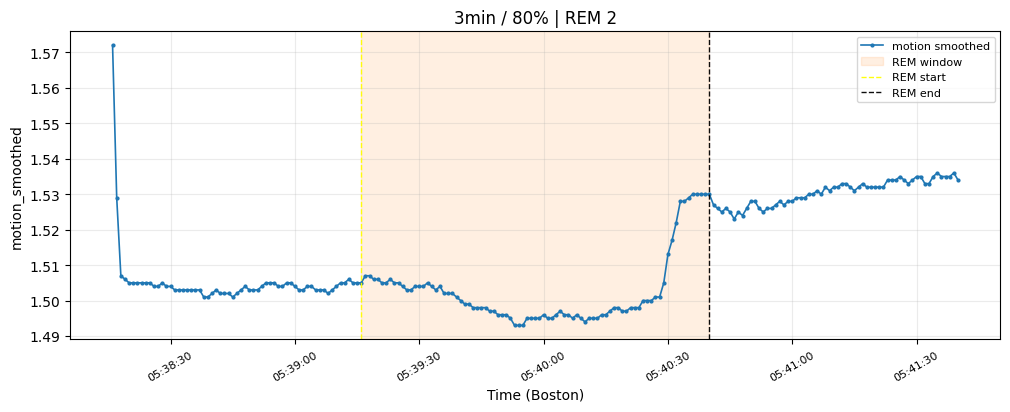

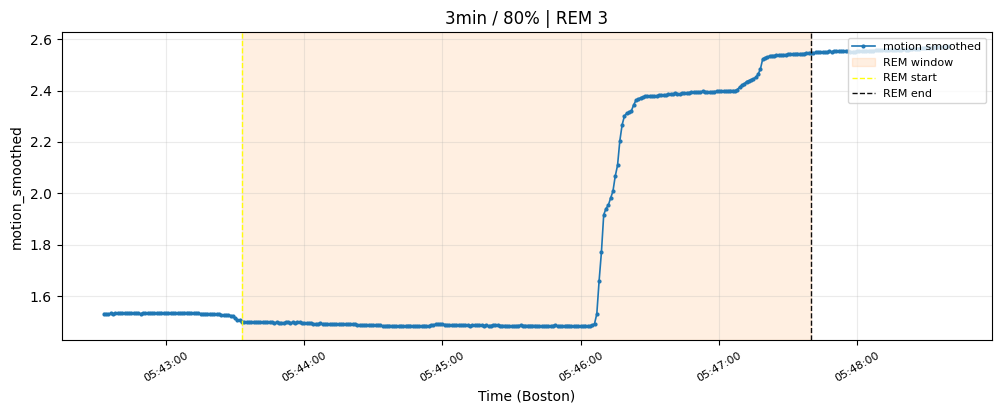

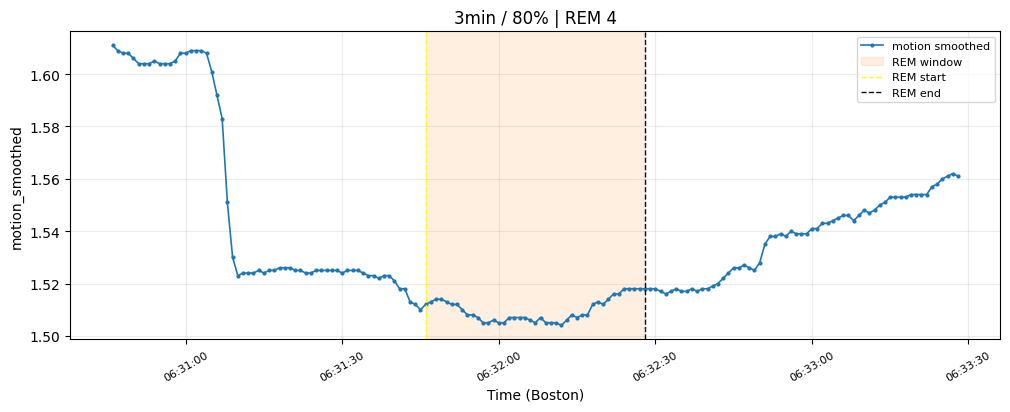

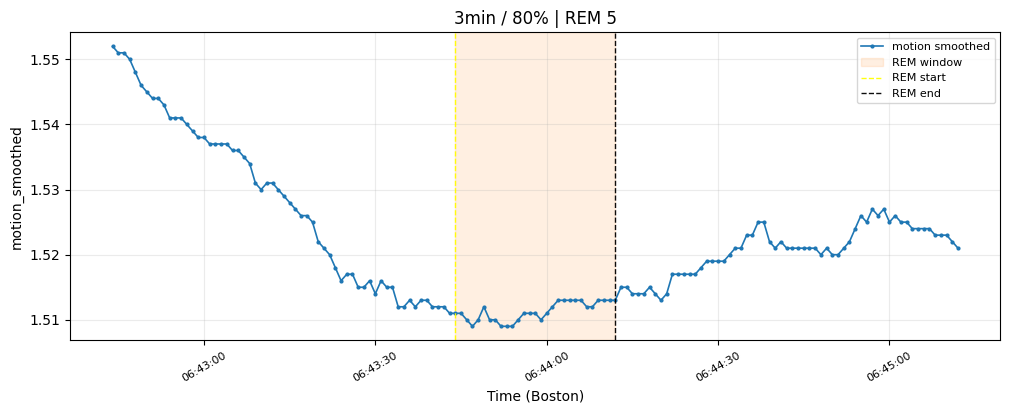

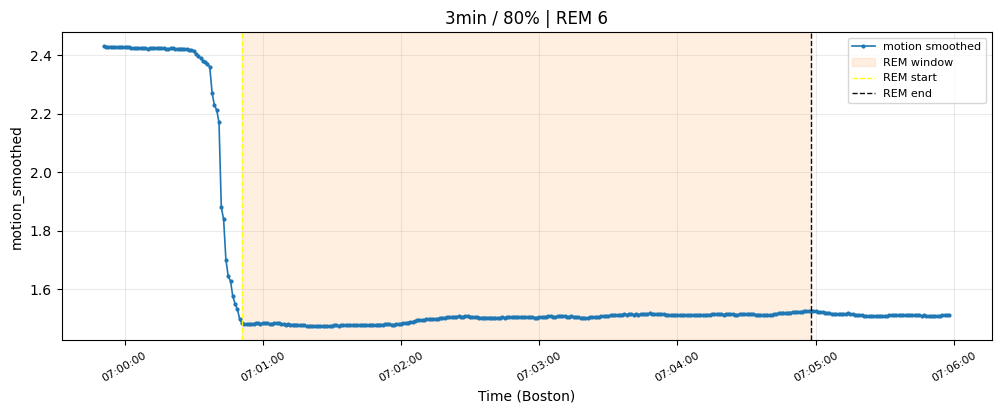

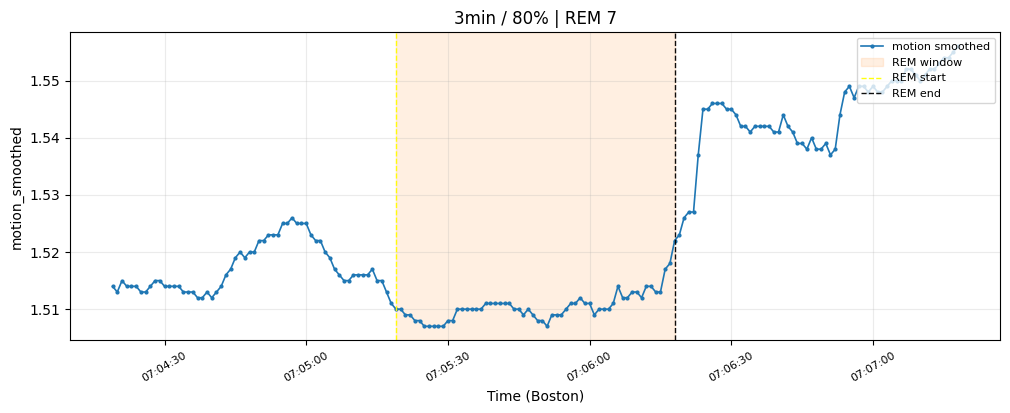

In [79]:
exp3_df, exp3_rem = run_experiment(
    window_sec=180,
    stillness_pct=0.80,
    label="3min / 80%"
)

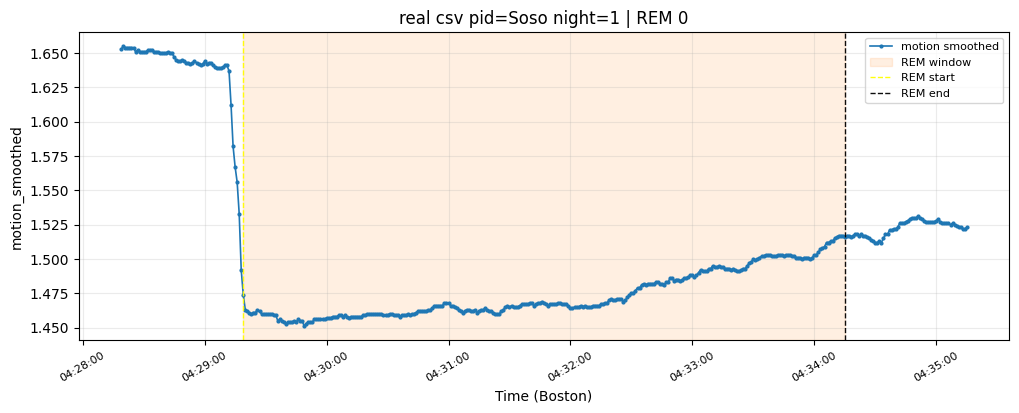

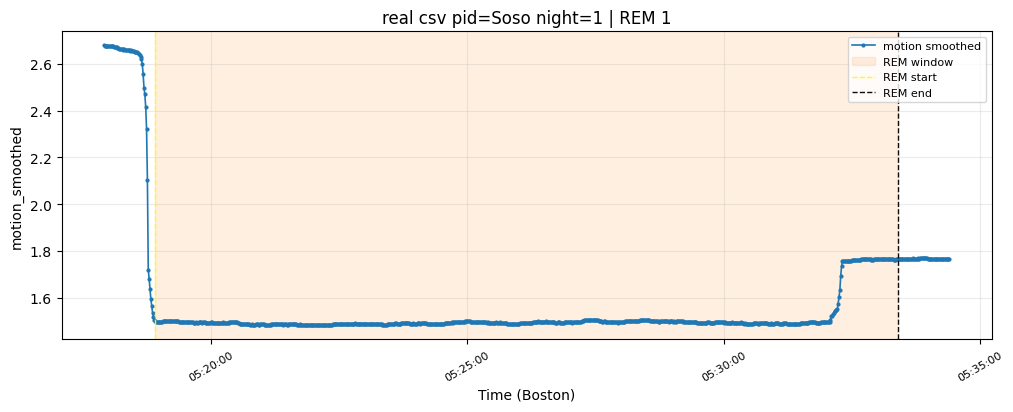

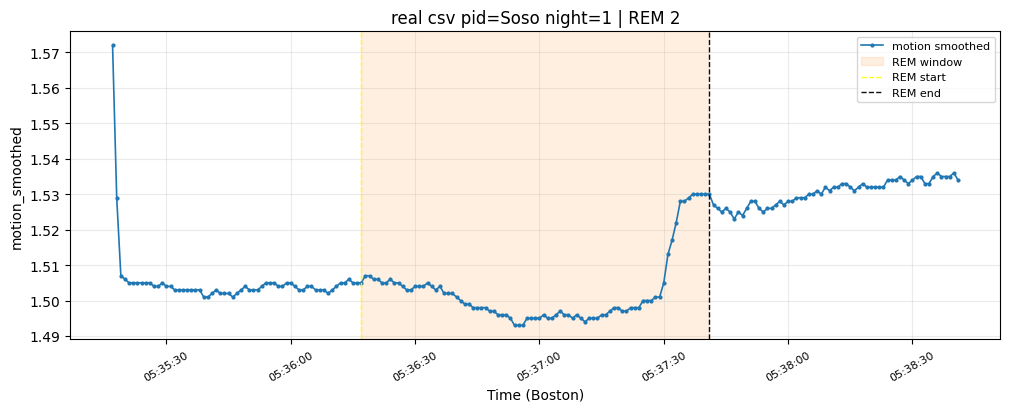

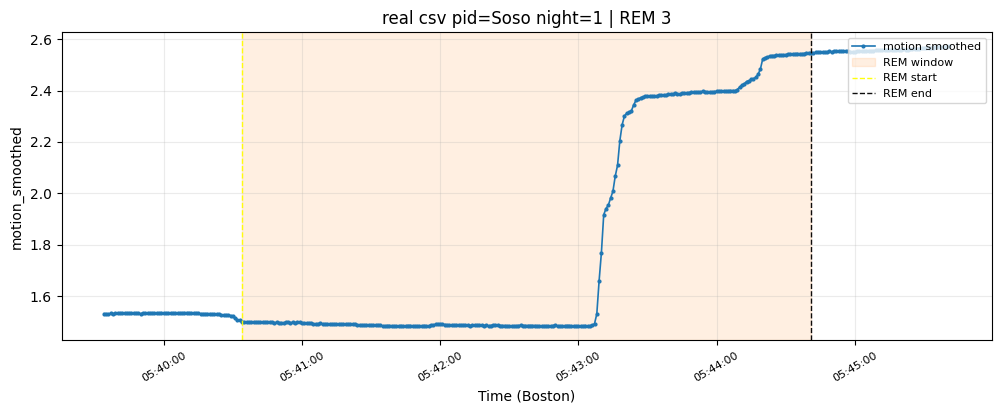

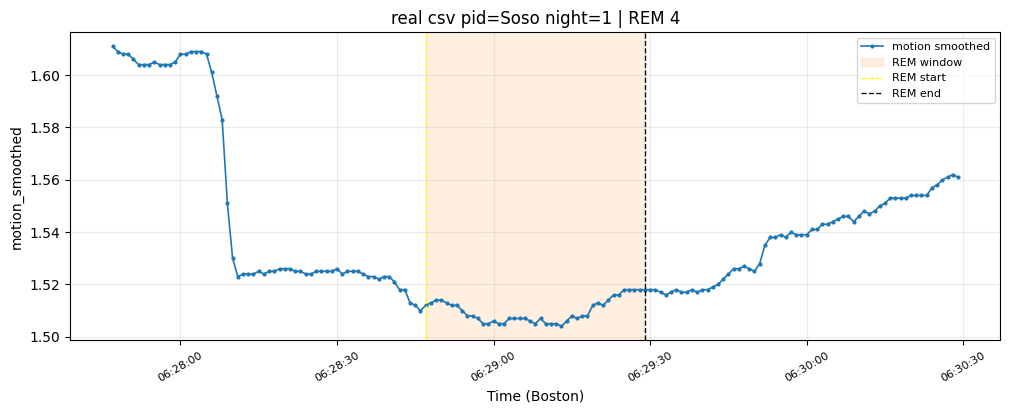

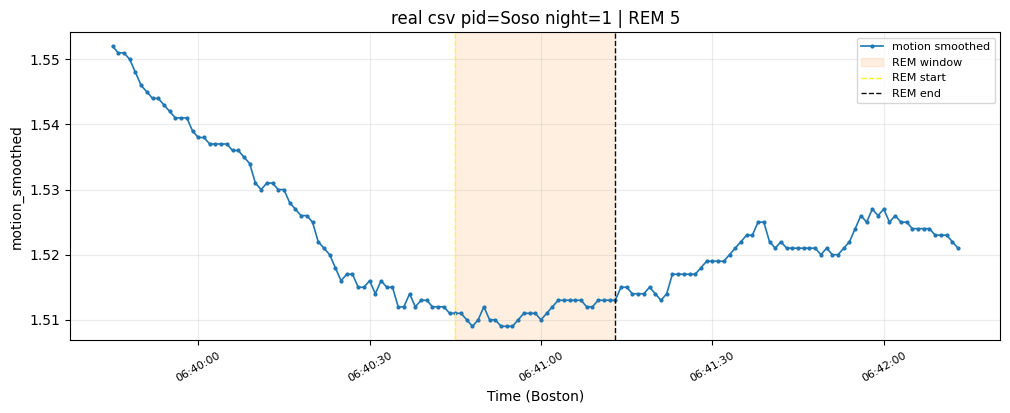

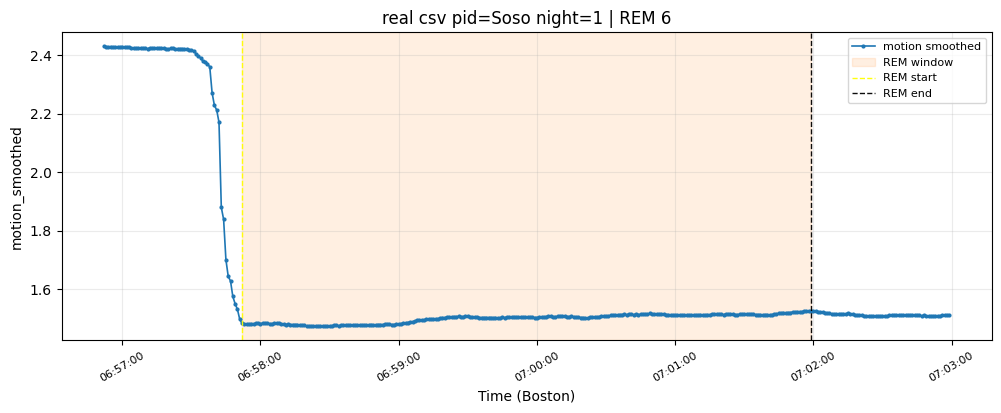

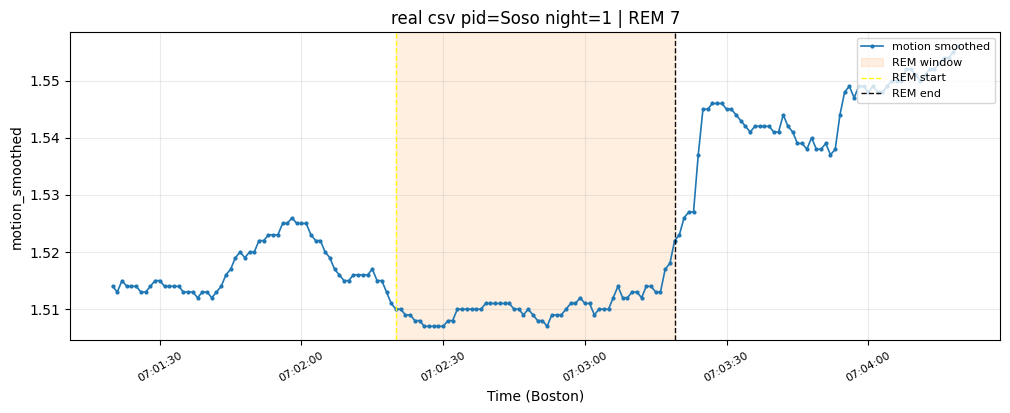

In [80]:
# Plot REAL REM phases using the same plotting function as fake REM.

def plot_real_rem_motion_exact(
    pid: str,
    night_number: int,
    rem_csv: Path = REM_CSV,
    motion_csv: Path = Path('/Users/solenenoize/Desktop/LuciDreams/plot/data_night/motion_smoothed_series.csv'),
    pre_sec: int = 60,
    post_sec: int = 60,
):
    rem = pd.read_csv(rem_csv)
    mot = pd.read_csv(motion_csv)

    rem = rem[rem['pid'].astype(str) == str(pid)].copy()
    mot = mot[mot['pid'].astype(str) == str(pid)].copy()

    if 'night_number' in rem.columns:
        rem['night_number'] = pd.to_numeric(rem['night_number'], errors='coerce')
        rem = rem[rem['night_number'] == int(night_number)].copy()
    if 'night_number' in mot.columns:
        mot['night_number'] = pd.to_numeric(mot['night_number'], errors='coerce')
        mot = mot[mot['night_number'] == int(night_number)].copy()

    if rem.empty:
        print(f'No REM rows for pid={pid}, night={night_number}')
        return
    if mot.empty:
        print(f'No motion rows for pid={pid}, night={night_number}')
        return

    rem_plot = rem.copy()
    rem_plot['episode_index'] = pd.to_numeric(rem_plot.get('episode_index'), errors='coerce')
    rem_plot['start_sec'] = pd.to_numeric(rem_plot.get('episode_start_epoch_sec'), errors='coerce')
    rem_plot['dur_sec'] = pd.to_numeric(rem_plot.get('episode_duration_sec'), errors='coerce')
    rem_plot = rem_plot.dropna(subset=['episode_index', 'start_sec', 'dur_sec']).copy()

    sec_to_val, sec_to_time = _build_motion_sec_maps(mot, sec_offset=REAL_SMOOTH_INDEX_OFFSET_SEC)
    plot_motion_per_rem(rem_plot, sec_to_val, sec_to_time, title_prefix=f'real csv pid={pid} night={night_number}', pre_sec=pre_sec, post_sec=post_sec)


# Run for Soso (real episodes only)
plot_real_rem_motion_exact(pid='Soso', night_number=NIGHT_NUMBER, pre_sec=60, post_sec=60)

In [81]:
# Quick diagnostic: compare simulation vs exported real REM for this pid/night
rem_real_csv = Path('/Users/solenenoize/Desktop/LuciDreams/plot/data_night/rem_episodes.csv')
real = pd.read_csv(rem_real_csv)
real = real[real['pid'].astype(str) == str(PID_MOTION)].copy()
if 'night_number' in real.columns:
    real['night_number'] = pd.to_numeric(real['night_number'], errors='coerce')
    real = real[real['night_number'] == int(NIGHT_NUMBER)].copy()
real['episode_start_epoch_sec'] = pd.to_numeric(real['episode_start_epoch_sec'], errors='coerce')
real['episode_duration_sec'] = pd.to_numeric(real['episode_duration_sec'], errors='coerce')
real = real.dropna(subset=['episode_start_epoch_sec', 'episode_duration_sec']).copy()
real['start_sec'] = real['episode_start_epoch_sec'].astype(int)
real['end_sec'] = (real['episode_start_epoch_sec'] + real['episode_duration_sec']).astype(int)
real = real[['start_sec','end_sec','episode_duration_sec']].reset_index(drop=True)

sim = exp3_rem[['start_sec','end_sec','duration_sec']].copy() if 'exp3_rem' in globals() else pd.DataFrame()
print(f'real episodes={len(real)} | sim episodes={len(sim)}')
if not sim.empty:
    n=min(len(real),len(sim))
    cmp = pd.DataFrame({
        'real_start': real['start_sec'].head(n).astype(int),
        'sim_start': sim['start_sec'].head(n).astype(int),
        'd_start': sim['start_sec'].head(n).astype(int).values - real['start_sec'].head(n).astype(int).values,
        'real_end': real['end_sec'].head(n).astype(int),
        'sim_end': sim['end_sec'].head(n).astype(int),
        'd_end': sim['end_sec'].head(n).astype(int).values - real['end_sec'].head(n).astype(int).values,
    })
    display(cmp)
else:
    print('Run an experiment cell first (e.g., exp3: 3min/80%).')

real episodes=8 | sim episodes=8


,real_start,sim_start,d_start,real_end,sim_end,d_end
0,16540,16540,0,16836,16836,0
1,19516,19516,0,20385,20385,0
2,20558,20558,0,20642,20642,0
3,20815,20815,0,21062,21062,0
4,23708,23708,0,23750,23750,0
5,24426,24426,0,24454,24454,0
6,25453,25453,0,25700,25700,0
7,25721,25721,0,25780,25780,0


In [82]:
# Extract smoothed motion values per REM period for both REAL and FAKE REM,
# so you can compare episode by episode.

def _sec_to_val_from_df(df: pd.DataFrame, value_col: str, sec_offset: int = 0) -> dict[int, float]:
    d = df.copy()
    d["second_index"] = pd.to_numeric(d.get("second_index"), errors="coerce")
    d[value_col] = pd.to_numeric(d.get(value_col), errors="coerce")
    d = d.dropna(subset=["second_index", value_col]).copy()
    d["second_index"] = d["second_index"].astype(int) + int(sec_offset)
    return {int(r["second_index"]): float(r[value_col]) for _, r in d.iterrows()}


def _extract_series_from_rem_df(rem_df: pd.DataFrame, sec_to_val: dict[int, float], kind: str) -> list[dict]:
    rows = []
    rr = rem_df.copy()

    # Accept both simulated schema and real CSV schema.
    if "start_sec" not in rr.columns:
        rr["start_sec"] = pd.to_numeric(rr.get("episode_start_epoch_sec"), errors="coerce")
    if "dur_sec" not in rr.columns:
        rr["dur_sec"] = pd.to_numeric(rr.get("duration_sec"), errors="coerce")
        if "dur_sec" not in rr.columns or rr["dur_sec"].isna().all():
            rr["dur_sec"] = pd.to_numeric(rr.get("episode_duration_sec"), errors="coerce")

    rr["episode_index"] = pd.to_numeric(rr.get("episode_index"), errors="coerce")
    rr = rr.dropna(subset=["episode_index", "start_sec", "dur_sec"]).copy()
    rr["episode_index"] = rr["episode_index"].astype(int)
    rr["start_sec"] = rr["start_sec"].astype(int)
    rr["dur_sec"] = rr["dur_sec"].astype(int)
    rr = rr.sort_values("episode_index")

    for _, ep in rr.iterrows():
        ep_idx = int(ep["episode_index"])
        s0 = int(ep["start_sec"])
        s1 = int(ep["start_sec"] + ep["dur_sec"])

        # Same interval convention used in plotting code: include both bounds.
        vals = [sec_to_val[sec] for sec in range(s0, s1 + 1) if sec in sec_to_val]

        rows.append({
            "kind": kind,
            "episode_index": ep_idx,
            "start_sec": s0,
            "end_sec": s1,
            "duration_sec": int(ep["dur_sec"]),
            "n_points": len(vals),
            "motion_smoothed_series": vals,
        })

    return rows


# ---------- REAL ----------
real_rem = pd.read_csv(REM_CSV)
real_motion = pd.read_csv('/Users/solenenoize/Desktop/LuciDreams/plot/data_night/motion_smoothed_series.csv')

real_rem = real_rem[real_rem['pid'].astype(str) == str(PID_MOTION)].copy()
real_motion = real_motion[real_motion['pid'].astype(str) == str(PID_MOTION)].copy()

if 'night_number' in real_rem.columns:
    real_rem['night_number'] = pd.to_numeric(real_rem['night_number'], errors='coerce')
    real_rem = real_rem[real_rem['night_number'] == int(NIGHT_NUMBER)].copy()
if 'night_number' in real_motion.columns:
    real_motion['night_number'] = pd.to_numeric(real_motion['night_number'], errors='coerce')
    real_motion = real_motion[real_motion['night_number'] == int(NIGHT_NUMBER)].copy()

# REAL values come directly from motion_smoothed_series.csv -> column motion_smoothed
real_sec_to_val = _sec_to_val_from_df(real_motion, value_col="motion_smoothed", sec_offset=REAL_SMOOTH_INDEX_OFFSET_SEC)
real_series_by_rem = _extract_series_from_rem_df(real_rem, real_sec_to_val, kind="real")

# ---------- FAKE (simulated) ----------
if 'exp3_df' not in globals() or 'exp3_rem' not in globals():
    raise RuntimeError("Run the fake REM experiment cell first (exp3_df / exp3_rem not found).")

fake_sec_to_val = _sec_to_val_from_df(exp3_df, value_col="motion_smoothed_exp", sec_offset=0)
# Ensure fake uses 10^-3 precision even if exp3_df comes from an older run.
fake_sec_to_val = {k: round(v, 3) for k, v in fake_sec_to_val.items()}
fake_series_by_rem = _extract_series_from_rem_df(exp3_rem, fake_sec_to_val, kind="fake")

# ---------- Side-by-side summary ----------
# Real and fake are now both 0-based episode_index.
real_summary = pd.DataFrame(real_series_by_rem)[["episode_index", "start_sec", "end_sec", "duration_sec", "n_points"]].rename(
    columns={
        "start_sec": "real_start_sec",
        "end_sec": "real_end_sec",
        "duration_sec": "real_duration_sec",
        "n_points": "real_n_points",
    }
).sort_values("episode_index")

fake_summary = pd.DataFrame(fake_series_by_rem)[["episode_index", "start_sec", "end_sec", "duration_sec", "n_points"]].rename(
    columns={
        "start_sec": "fake_start_sec",
        "end_sec": "fake_end_sec",
        "duration_sec": "fake_duration_sec",
        "n_points": "fake_n_points",
    }
).sort_values("episode_index")

compare_df = real_summary.merge(fake_summary, on="episode_index", how="outer").sort_values("episode_index")

print(f"real episodes extracted: {len(real_series_by_rem)}")
print(f"fake episodes extracted: {len(fake_series_by_rem)}")
print("index convention: real=0-based, fake=0-based")
display(compare_df)

# Optional: inspect exact arrays by 0-based episode_index
EP_TO_INSPECT = 0
real_ep = next((x for x in real_series_by_rem if x["episode_index"] == EP_TO_INSPECT), None)
fake_ep = next((x for x in fake_series_by_rem if x["episode_index"] == EP_TO_INSPECT), None)

print(f"\nEpisode index {EP_TO_INSPECT} real points:", 0 if real_ep is None else len(real_ep["motion_smoothed_series"]))
print(f"Episode index {EP_TO_INSPECT} fake points:", 0 if fake_ep is None else len(fake_ep["motion_smoothed_series"]))

# Keep these variables for manual comparison/copy-paste
real_series_by_rem, fake_series_by_rem, compare_df

real episodes extracted: 8
fake episodes extracted: 8
index convention: real=0-based, fake=0-based


,episode_index,real_start_sec,real_end_sec,real_duration_sec,real_n_points,fake_start_sec,fake_end_sec,fake_duration_sec,fake_n_points
0,0,16540,16836,296,297,16540,16836,296,297
1,1,19516,20385,869,870,19516,20385,869,870
2,2,20558,20642,84,85,20558,20642,84,85
3,3,20815,21062,247,248,20815,21062,247,248
4,4,23708,23750,42,43,23708,23750,42,43
5,5,24426,24454,28,29,24426,24454,28,29
6,6,25453,25700,247,248,25453,25700,247,248
7,7,25721,25780,59,60,25721,25780,59,60



Episode index 0 real points: 297
Episode index 0 fake points: 297


([{'kind': 'real',
   'episode_index': 0,
   'start_sec': 16540,
   'end_sec': 16836,
   'duration_sec': 296,
   'n_points': 297,
   'motion_smoothed_series': [1.474,
    1.463,
    1.462,
    1.461,
    1.46,
    1.461,
    1.461,
    1.463,
    1.462,
    1.46,
    1.46,
    1.46,
    1.46,
    1.46,
    1.46,
    1.459,
    1.459,
    1.455,
    1.456,
    1.455,
    1.454,
    1.453,
    1.454,
    1.454,
    1.454,
    1.455,
    1.454,
    1.456,
    1.455,
    1.455,
    1.451,
    1.453,
    1.454,
    1.454,
    1.454,
    1.456,
    1.456,
    1.456,
    1.456,
    1.456,
    1.456,
    1.457,
    1.457,
    1.457,
    1.458,
    1.458,
    1.458,
    1.459,
    1.459,
    1.458,
    1.459,
    1.458,
    1.457,
    1.458,
    1.458,
    1.458,
    1.458,
    1.458,
    1.458,
    1.459,
    1.459,
    1.46,
    1.46,
    1.46,
    1.46,
    1.46,
    1.46,
    1.46,
    1.46,
    1.459,
    1.459,
    1.459,
    1.46,
    1.46,
    1.459,
    1.459,
    1.459,
    1.458,
   

In [83]:
# Show FULL motion-smoothed list for each REM (no truncation), real vs fake.
# Requires previous extraction cell to be executed first.
import json

if 'real_series_by_rem' not in globals() or 'fake_series_by_rem' not in globals():
    raise RuntimeError('Run the extraction cell first (real_series_by_rem / fake_series_by_rem not found).')

real_map = {int(x['episode_index']): x['motion_smoothed_series'] for x in real_series_by_rem}
fake_map = {int(x['episode_index']): x['motion_smoothed_series'] for x in fake_series_by_rem}
all_eps = sorted(set(real_map.keys()) | set(fake_map.keys()))

for ep in all_eps:
    print(f"\n================ REM {ep} ================")
    r = real_map.get(ep)
    f = fake_map.get(ep)

    if r is None:
        print('REAL: <missing>')
    else:
        print(f'REAL (n={len(r)}):')
        print(json.dumps(r, ensure_ascii=False))

    if f is None:
        print('FAKE: <missing>')
    else:
        print(f'FAKE (n={len(f)}):')
        print(json.dumps(f, ensure_ascii=False))

    if r is not None and f is not None:
        same = (len(r) == len(f)) and all((abs(float(a) - float(b)) <= 1e-9) for a, b in zip(r, f))
        print('IDENTICAL:', same)

# Optional: save full lists to JSON files for side-by-side diff in editor
with open('/Users/solenenoize/Desktop/LuciDreams/plot/data_night/real_series_by_rem_full.json', 'w', encoding='utf-8') as f:
    json.dump(real_series_by_rem, f, ensure_ascii=False, indent=2)
with open('/Users/solenenoize/Desktop/LuciDreams/plot/data_night/fake_series_by_rem_full.json', 'w', encoding='utf-8') as f:
    json.dump(fake_series_by_rem, f, ensure_ascii=False, indent=2)

print('\nSaved:')
print(' - plot/data_night/real_series_by_rem_full.json')
print(' - plot/data_night/fake_series_by_rem_full.json')


================ REM 0 ================
REAL (n=297):
[1.474, 1.463, 1.462, 1.461, 1.46, 1.461, 1.461, 1.463, 1.462, 1.46, 1.46, 1.46, 1.46, 1.46, 1.46, 1.459, 1.459, 1.455, 1.456, 1.455, 1.454, 1.453, 1.454, 1.454, 1.454, 1.455, 1.454, 1.456, 1.455, 1.455, 1.451, 1.453, 1.454, 1.454, 1.454, 1.456, 1.456, 1.456, 1.456, 1.456, 1.456, 1.457, 1.457, 1.457, 1.458, 1.458, 1.458, 1.459, 1.459, 1.458, 1.459, 1.458, 1.457, 1.458, 1.458, 1.458, 1.458, 1.458, 1.458, 1.459, 1.459, 1.46, 1.46, 1.46, 1.46, 1.46, 1.46, 1.46, 1.46, 1.459, 1.459, 1.459, 1.46, 1.46, 1.459, 1.459, 1.459, 1.458, 1.459, 1.459, 1.459, 1.46, 1.459, 1.46, 1.46, 1.461, 1.462, 1.462, 1.462, 1.462, 1.462, 1.463, 1.463, 1.464, 1.466, 1.466, 1.466, 1.466, 1.466, 1.468, 1.468, 1.468, 1.466, 1.466, 1.465, 1.464, 1.463, 1.462, 1.461, 1.462, 1.463, 1.463, 1.462, 1.462, 1.463, 1.461, 1.462, 1.463, 1.463, 1.464, 1.463, 1.462, 1.462, 1.461, 1.46, 1.46, 1.46, 1.462, 1.463, 1.465, 1.466, 1.465, 1.466, 1.465, 1.465, 1.465, 1.466, 1.467, 1

In [84]:
# Compare FULL fake vs real smoothed series and count non-equal values.
# Assumes exp3_df exists and real motion CSV is exported for the same pid/night.

if 'exp3_df' not in globals():
    raise RuntimeError('Run the fake experiment cell first so exp3_df exists.')

# Real full series (already smoothed from app/export)
real_full_df = pd.read_csv('/Users/solenenoize/Desktop/LuciDreams/plot/data_night/motion_smoothed_series.csv')
real_full_df = real_full_df[real_full_df['pid'].astype(str) == str(PID_MOTION)].copy()
if 'night_number' in real_full_df.columns:
    real_full_df['night_number'] = pd.to_numeric(real_full_df['night_number'], errors='coerce')
    real_full_df = real_full_df[real_full_df['night_number'] == int(NIGHT_NUMBER)].copy()

real_full_df['second_index'] = pd.to_numeric(real_full_df.get('second_index'), errors='coerce')
real_full_df['motion_smoothed'] = pd.to_numeric(real_full_df.get('motion_smoothed'), errors='coerce')
real_full_df = real_full_df.dropna(subset=['second_index', 'motion_smoothed']).copy()
real_full_df['second_index'] = real_full_df['second_index'].astype(int)
real_full_df = real_full_df.sort_values('second_index').reset_index(drop=True)
real_full = real_full_df['motion_smoothed'].round(1).tolist()

# Fake full series from exp3 (already rounded in run_experiment, but keep defensive round)
fake_full_df = exp3_df.copy()
fake_full_df['second_index'] = pd.to_numeric(fake_full_df.get('second_index'), errors='coerce')
fake_full_df['motion_smoothed_exp'] = pd.to_numeric(fake_full_df.get('motion_smoothed_exp'), errors='coerce')
fake_full_df = fake_full_df.dropna(subset=['second_index', 'motion_smoothed_exp']).copy()
fake_full_df['second_index'] = fake_full_df['second_index'].astype(int)
fake_full_df = fake_full_df.sort_values('second_index').reset_index(drop=True)
fake_full = fake_full_df['motion_smoothed_exp'].round(1).tolist()

n_common = min(len(real_full), len(fake_full))
neq = 0
mismatch_positions = []
for i in range(n_common):
    if real_full[i] != fake_full[i]:
        neq += 1
        mismatch_positions.append({
            'pos': i,
            'real': real_full[i],
            'fake': fake_full[i],
        })

len_diff = abs(len(real_full) - len(fake_full))
neq_total = neq + len_diff

print(f'real_len={len(real_full)}')
print(f'fake_len={len(fake_full)}')
print(f'compared_len={n_common}')
print(f'not_equal_in_overlap={neq}')
print(f'length_difference={len_diff}')
print(f'not_equal_total={neq_total}')

mismatch_df = pd.DataFrame(mismatch_positions)
if not mismatch_df.empty:
    display(mismatch_df)
else:
    print('No value mismatch in overlap.')

# Save full non-equal list to file
mismatch_json_path = '/Users/solenenoize/Desktop/LuciDreams/plot/data_night/non_equal_values_full.json'
mismatch_csv_path = '/Users/solenenoize/Desktop/LuciDreams/plot/data_night/non_equal_values_full.csv'

mismatch_df.to_csv(mismatch_csv_path, index=False)
import json
with open(mismatch_json_path, 'w', encoding='utf-8') as f:
    json.dump(mismatch_positions, f, ensure_ascii=False, indent=2)

print('\nSaved full mismatch list:')
print(f' - {mismatch_json_path}')
print(f' - {mismatch_csv_path}')

real_len=32676
fake_len=32676
compared_len=32676
not_equal_in_overlap=6
length_difference=0
not_equal_total=6


,pos,real,fake
0,209,2.1,2.0
1,5412,1.5,1.6
2,15624,1.9,1.8
3,27921,1.7,1.8
4,28584,2.1,2.2
5,30963,2.9,2.8



Saved full mismatch list:
 - /Users/solenenoize/Desktop/LuciDreams/plot/data_night/non_equal_values_full.json
 - /Users/solenenoize/Desktop/LuciDreams/plot/data_night/non_equal_values_full.csv
